In [1]:
# ============================================================
# Step 1: Import Required Libraries
# ============================================================

from ultralytics import YOLO
import torch
import os
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
# ============================================================
# Step 2: Check GPU and Environment
# ============================================================

print("=" * 50)
print("PyTorch Version :", torch.__version__)
print("CUDA Available  :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name        :", torch.cuda.get_device_name(0))
    print("CUDA Version    :", torch.version.cuda)
else:
    print("Running on CPU")

print("=" * 50)

PyTorch Version : 2.12.1+cu126
CUDA Available  : True
GPU Name        : NVIDIA GeForce RTX 3050 6GB Laptop GPU
CUDA Version    : 12.6


In [3]:
# ============================================================
# 🔴 Step 3: Verify Dataset Structure
# Run Only Once
# ============================================================

import os
import yaml

dataset_path = r"D:\Major Project\Self-Driving Cars.yolov8"

print("=" * 60)
print("Traffic Sign Detection Dataset Verification")
print("=" * 60)

# Check Dataset Folder
if os.path.exists(dataset_path):
    print(f"✅ Dataset Folder Found: {dataset_path}")
else:
    print("❌ Dataset Folder Not Found!")

# Required Folders
folders = ["train", "valid", "test"]

for folder in folders:
    folder_path = os.path.join(dataset_path, folder)

    if os.path.exists(folder_path):
        print(f"✅ {folder} folder found")

        images = os.path.join(folder_path, "images")
        labels = os.path.join(folder_path, "labels")

        print(f"   Images Folder : {'✅' if os.path.exists(images) else '❌'}")
        print(f"   Labels Folder : {'✅' if os.path.exists(labels) else '❌'}")

    else:
        print(f"❌ {folder} folder missing")

# Check data.yaml
yaml_path = os.path.join(dataset_path, "data.yaml")

print("\n" + "=" * 60)

if os.path.exists(yaml_path):
    print("✅ data.yaml Found")

    with open(yaml_path, "r") as f:
        data = yaml.safe_load(f)

    print("\nDataset Information")
    print("-" * 40)
    print(f"Number of Classes : {data['nc']}")
    print(f"Class Names       : {data['names']}")

else:
    print("❌ data.yaml Missing")

print("=" * 60)

Traffic Sign Detection Dataset Verification
✅ Dataset Folder Found: D:\Major Project\Self-Driving Cars.yolov8
✅ train folder found
   Images Folder : ✅
   Labels Folder : ✅
✅ valid folder found
   Images Folder : ✅
   Labels Folder : ✅
✅ test folder found
   Images Folder : ✅
   Labels Folder : ✅

✅ data.yaml Found

Dataset Information
----------------------------------------
Number of Classes : 15
Class Names       : ['Green Light', 'Red Light', 'Speed Limit 10', 'Speed Limit 100', 'Speed Limit 110', 'Speed Limit 120', 'Speed Limit 20', 'Speed Limit 30', 'Speed Limit 40', 'Speed Limit 50', 'Speed Limit 60', 'Speed Limit 70', 'Speed Limit 80', 'Speed Limit 90', 'Stop']


In [4]:
# ============================================================
# 🔴 Step 4: Load YOLOv11n Pretrained Model
# Run Only Once
# ============================================================

from ultralytics import YOLO

print("=" * 60)
print("Loading YOLOv11n Pretrained Model...")
print("=" * 60)

# Load YOLOv11 Nano pretrained model
model = YOLO("yolo11n.pt")

print("\n✅ YOLOv11n model loaded successfully!")
print("=" * 60)

# Display model architecture
model.info()

Loading YOLOv11n Pretrained Model...

✅ YOLOv11n model loaded successfully!
YOLO11n summary: 181 layers, 2,624,080 parameters, 0 gradients, 6.6 GFLOPs


(181, 2624080, 0, 6.614336)

In [5]:
# ============================================================
# 🔴 Step 5: Configure Training Parameters
# Run Only Once
# ============================================================

# Dataset Configuration
DATA_YAML = r"D:\Major Project\Self-Driving Cars.yolov8\data.yaml"

# Training Configuration
IMG_SIZE = 640
EPOCHS = 50                 # Maximum epochs
BATCH_SIZE = 16
DEVICE = 0                  # GPU
WORKERS = 0

# Early Stopping
PATIENCE = 10               # Stop if no improvement for 10 epochs

# Optimizer
OPTIMIZER = "auto"

# Random Seed
SEED = 42

# Project Configuration
PROJECT_NAME = r"D:\Major Project\Models"
RUN_NAME = "YOLOv11n"

print("=" * 60)
print("YOLOv11 Training Configuration")
print("=" * 60)

print(f"Dataset Path      : {DATA_YAML}")
print(f"Image Size        : {IMG_SIZE}")
print(f"Maximum Epochs    : {EPOCHS}")
print(f"Batch Size        : {BATCH_SIZE}")
print(f"Device            : GPU ({DEVICE})")
print(f"Workers           : {WORKERS}")
print(f"Optimizer         : {OPTIMIZER}")
print(f"Early Stopping    : {PATIENCE} epochs")
print(f"Random Seed       : {SEED}")
print(f"Project Name      : {PROJECT_NAME}")
print(f"Run Name          : {RUN_NAME}")

print("=" * 60)

YOLOv11 Training Configuration
Dataset Path      : D:\Major Project\Self-Driving Cars.yolov8\data.yaml
Image Size        : 640
Maximum Epochs    : 50
Batch Size        : 16
Device            : GPU (0)
Workers           : 0
Optimizer         : auto
Early Stopping    : 10 epochs
Random Seed       : 42
Project Name      : D:\Major Project\Models
Run Name          : YOLOv11n


In [6]:
# ============================================================
# 🔴 Step 6: Train YOLOv11n Model
# Run Only Once
# ============================================================

print("=" * 60)
print("Starting YOLOv11n Training...")
print("=" * 60)

results = model.train(

    # Dataset
    data=DATA_YAML,

    # Training Parameters
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,

    # Hardware
    device=DEVICE,
    workers=WORKERS,

    # Project Settings
    project=PROJECT_NAME,
    name=RUN_NAME,
    exist_ok=True,

    # Training Settings
    pretrained=True,
    optimizer=OPTIMIZER,
    patience=PATIENCE,
    seed=SEED,

    # Mixed Precision
    amp=True,

    # Save Best Model
    save=True,

    # Generate validation plots
    plots=True,

    # Verbose Output
    verbose=True
)

print("\n" + "=" * 60)
print("✅ Training Completed Successfully!")
print("=" * 60)

Starting YOLOv11n Training...
New https://pypi.org/project/ultralytics/8.4.104 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.80  Python-3.12.10 torch-2.12.1+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\Major Project\Self-Driving Cars.yolov8\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, 

In [7]:
# ============================================================
# 🟢 Step 7: Load Best YOLOv11n Model
# Can Be Run Anytime
# ============================================================

from ultralytics import YOLO
import os

# Path to the best trained model
BEST_MODEL_PATH = r"D:\Major Project\Models\YOLOv11n\weights\best.pt"

print("=" * 60)
print("Loading Best YOLOv11n Model...")
print("=" * 60)

# Check whether the model exists
if os.path.exists(BEST_MODEL_PATH):
    print(f"✅ Best model found!")
    print(f"📁 Location : {BEST_MODEL_PATH}")
    
    # Load best model
    best_model = YOLO(BEST_MODEL_PATH)

    print("\n✅ Best model loaded successfully!")
    print("=" * 60)

    # Display model architecture
    best_model.info()

else:
    print("❌ best.pt not found!")

Loading Best YOLOv11n Model...
✅ Best model found!
📁 Location : D:\Major Project\Models\YOLOv11n\weights\best.pt

✅ Best model loaded successfully!
YOLO11n summary: 182 layers, 2,592,765 parameters, 0 gradients, 6.5 GFLOPs


In [8]:
# ============================================================
# 🟢 Step 8: Validate Best YOLOv11n Model
# Can Be Run Anytime
# ============================================================

print("=" * 60)
print("Validating Best YOLOv11n Model...")
print("=" * 60)

# Validate best model
metrics = best_model.val(
    data=DATA_YAML,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    workers=WORKERS,
    split="val",
    plots=True,
    save_json=False,
    verbose=True
)

print("\n" + "=" * 60)
print("✅ Validation Completed Successfully!")
print("=" * 60)

# Print Overall Performance
print(f"Precision   : {metrics.box.mp:.4f}")
print(f"Recall      : {metrics.box.mr:.4f}")
print(f"mAP@50      : {metrics.box.map50:.4f}")
print(f"mAP@50-95   : {metrics.box.map:.4f}")

Validating Best YOLOv11n Model...
Ultralytics 8.4.80  Python-3.12.10 torch-2.12.1+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
YOLO11n summary (fused): 101 layers, 2,585,077 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 314.5225.1 MB/s, size: 52.0 KB)
val: Scanning D:\Major Project\Self-Driving Cars.yolov8\valid\labels.cache... 801 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 801/801  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 51/51 2.9it/s 17.9s0.3s
                   all        801        944      0.959       0.92      0.968      0.834
           Green Light         87        122      0.868      0.757       0.88      0.515
             Red Light         74        108       0.87      0.747      0.834      0.521
       Speed Limit 100         52         52      0.969      0.942      0.993      0.897
       Speed Limit 110         17         17       0.91 

In [1]:
# ============================================================
# 🟢 Step 9A: Import Libraries & Load Best YOLOv11 Model
# Run Once After Every Kernel Restart
# ============================================================

from ultralytics import YOLO
from tkinter import Tk, filedialog
import matplotlib.pyplot as plt
from IPython.display import display
import cv2
import os
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Load Best Model
# ------------------------------------------------------------
BEST_MODEL_PATH = r"D:\Major Project\Models\YOLOv11n\weights\best.pt"

print("=" * 60)
print("Loading Best YOLOv11 Model...")
print("=" * 60)

best_model = YOLO(BEST_MODEL_PATH)

print("✅ Model Loaded Successfully!")
print(f"📁 Model Path: {BEST_MODEL_PATH}")

print("=" * 60)

Loading Best YOLOv11 Model...
✅ Model Loaded Successfully!
📁 Model Path: D:\Major Project\Models\YOLOv11n\weights\best.pt


Selected Image: D:/Major Project/Test_images/speed80.jpeg

ORIGINAL


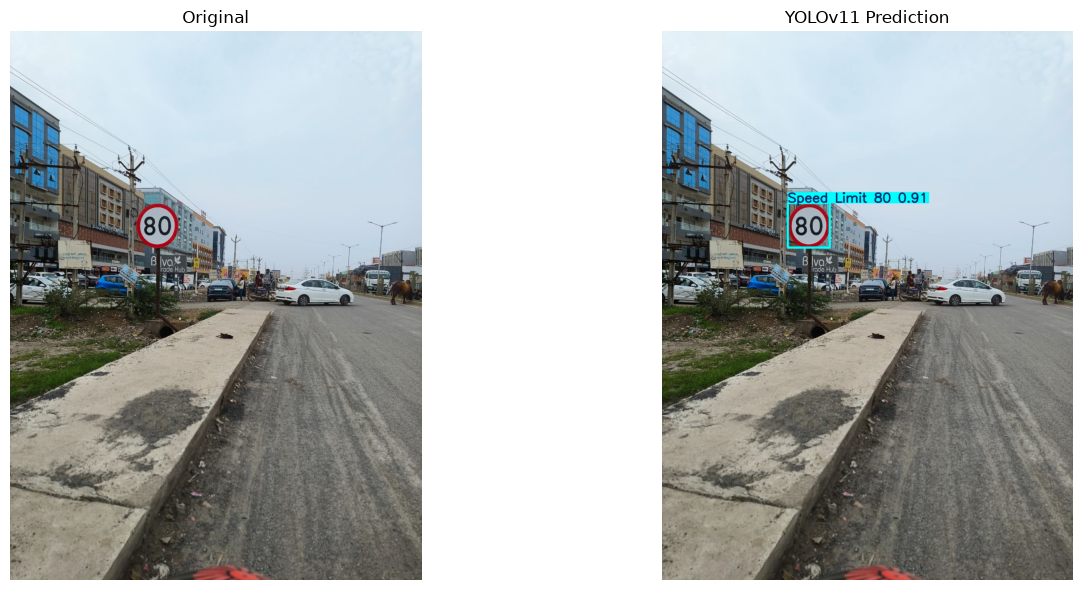

,No.,Traffic Sign,Confidence (%),Width (px),Height (px)
0,1,Speed Limit 80,91.02,98,104


✅ Total Traffic Signs Detected : 1

NIGHT VISION


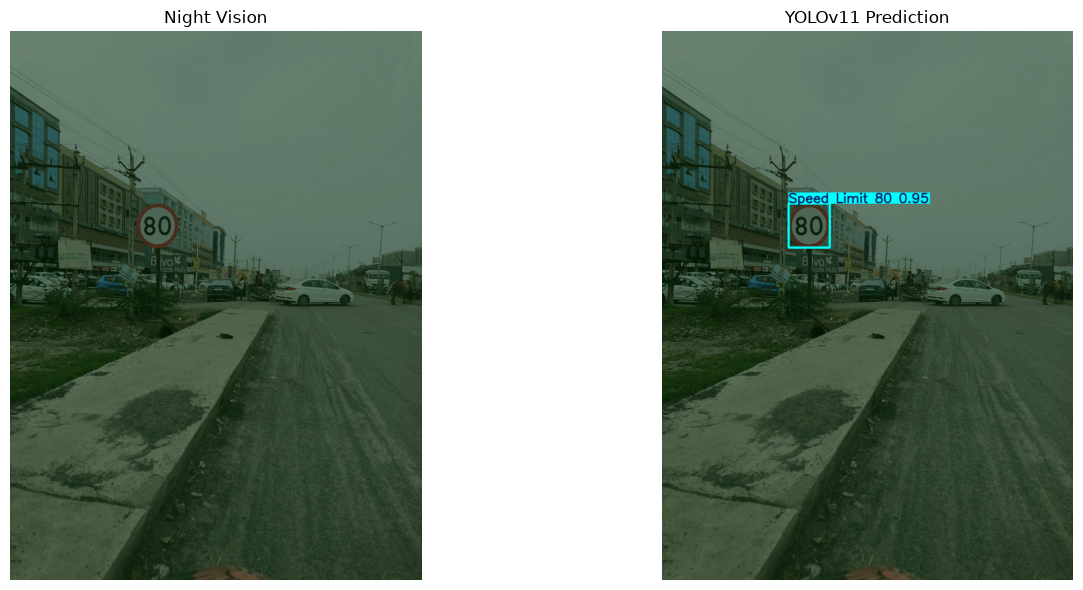

,No.,Traffic Sign,Confidence (%),Width (px),Height (px)
0,1,Speed Limit 80,95.27,96,103


✅ Total Traffic Signs Detected : 1

FOG


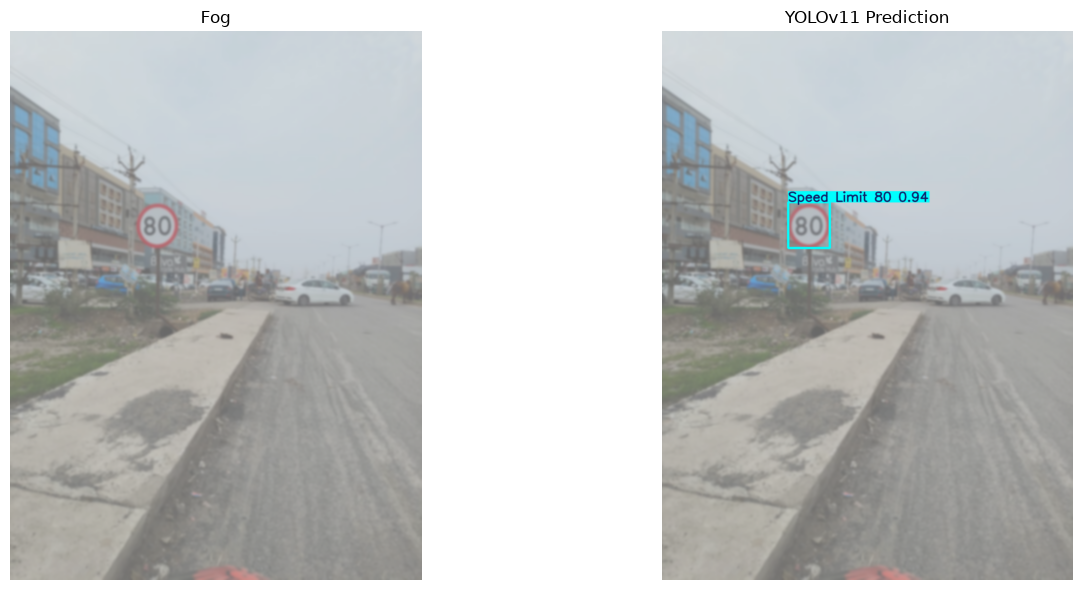

,No.,Traffic Sign,Confidence (%),Width (px),Height (px)
0,1,Speed Limit 80,94.32,97,107


✅ Total Traffic Signs Detected : 1

RAIN


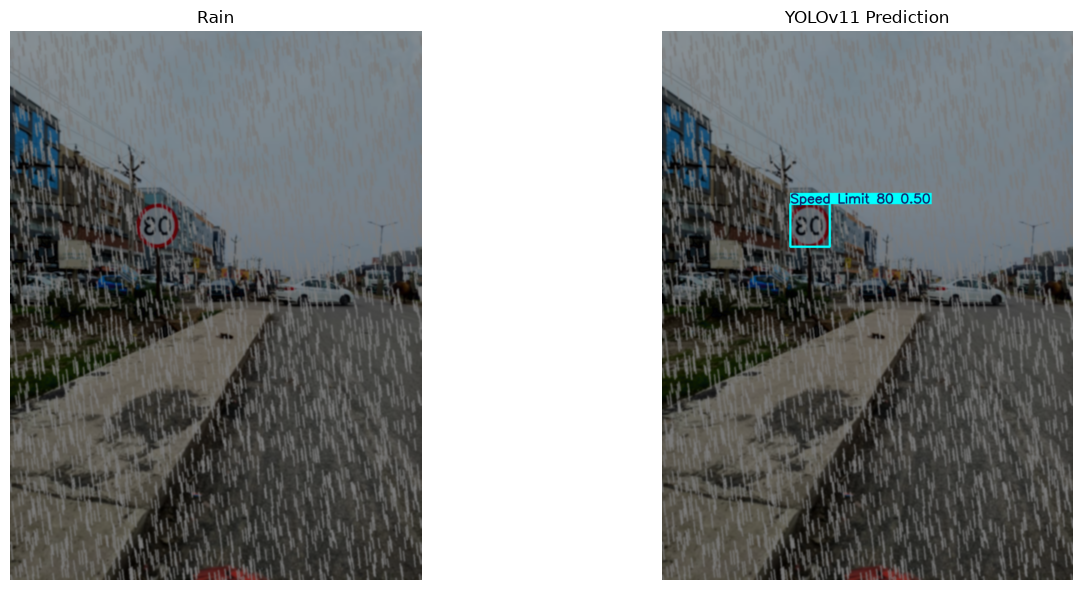

,No.,Traffic Sign,Confidence (%),Width (px),Height (px)
0,1,Speed Limit 80,49.84,92,100


✅ Total Traffic Signs Detected : 1

GAUSSIAN BLUR


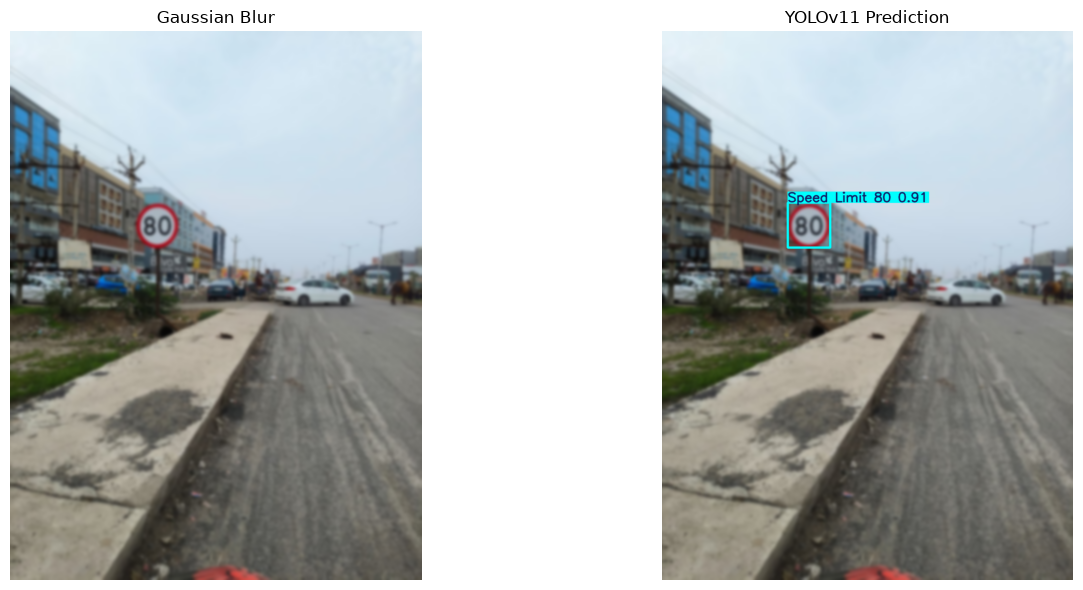

,No.,Traffic Sign,Confidence (%),Width (px),Height (px)
0,1,Speed Limit 80,91.05,99,105


✅ Total Traffic Signs Detected : 1


In [4]:
# ==========================================================
# Test Original + Filtered Images (YOLOv11n)
# ==========================================================

def night_vision(img):
    img = img.copy()

    # Convert BGR → HSV
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV).astype(np.float32)

    # Darken image
    hsv[:, :, 2] *= 0.45

    # Reduce saturation
    hsv[:, :, 1] *= 0.70

    hsv[:, :, 2] = np.clip(hsv[:, :, 2], 0, 255)
    hsv[:, :, 1] = np.clip(hsv[:, :, 1], 0, 255)

    # Convert HSV → BGR
    night = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)

    # Slight green tint
    night[:, :, 1] = cv2.add(night[:, :, 1], 20)

    return night

def fog_filter(img):

    img = img.copy()

    h, w = img.shape[:2]

    # White fog layer
    fog = np.full((h, w, 3), 255, dtype=np.uint8)

    # Dense fog
    foggy = cv2.addWeighted(img, 0.60, fog, 0.40, 0)

    # Strong blur
    foggy = cv2.GaussianBlur(foggy, (15, 15), 0)

    # Lower contrast
    foggy = cv2.convertScaleAbs(
        foggy,
        alpha=0.80,
        beta=20
    )

    return foggy


def rain_filter(img):

    rain = img.copy()

    h, w = rain.shape[:2]

    # Dense rain
    for _ in range(3500):

        x = np.random.randint(0, w)
        y = np.random.randint(0, h)

        length = np.random.randint(18, 35)

        cv2.line(
            rain,
            (x, y),
            (x + 3, y + length),
            (210, 210, 210),
            2
        )

    # Heavy blur
    rain = cv2.GaussianBlur(rain, (9, 9), 1.8)

    # Darker rainy weather
    rain = cv2.convertScaleAbs(
        rain,
        alpha=0.65,
        beta=-15
    )

    return rain

def gaussian_filter(img):

    img = img.copy()

    return cv2.GaussianBlur(img, (21, 21), 0)
# ---------------- Select Image ----------------

root = Tk()
root.withdraw()
root.attributes("-topmost", True)

image_path = filedialog.askopenfilename(
    title="Select Traffic Sign Image",
    filetypes=[("Image Files", "*.jpg *.jpeg *.png *.bmp *.webp")]
)

root.destroy()

if image_path == "":
    print("No image selected.")
    raise SystemExit

print("Selected Image:", image_path)

# Read image in BGR
original = cv2.imread(image_path)

images = {
    "Original": original.copy(),
    "Night Vision": night_vision(original.copy()),
    "Fog": fog_filter(original.copy()),
    "Rain": rain_filter(original.copy()),
    "Gaussian Blur": gaussian_filter(original.copy())
}

for title, img in images.items():

    print("\n" + "=" * 70)
    print(title.upper())
    print("=" * 70)

    # ---------------- Prediction ----------------
    results = best_model.predict(
        source=img,
        imgsz=640,
        conf=0.25,
        save=False,
        verbose=False
    )

    # Draw detections
    predicted = results[0].plot()

    # Convert for matplotlib display
    display_original = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    display_prediction = cv2.cvtColor(predicted, cv2.COLOR_BGR2RGB)

    # ---------------- Display ----------------
    plt.figure(figsize=(15,6))

    plt.subplot(1,2,1)
    plt.imshow(display_original)
    plt.title(title)
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(display_prediction)
    plt.title("YOLOv11 Prediction")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # ---------------- Detection Summary ----------------
    boxes = results[0].boxes
    names = best_model.names

    if len(boxes) == 0:
        print("❌ No Traffic Signs Detected.")
        continue

    detection_list = []

    for i, box in enumerate(boxes):

        class_id = int(box.cls[0])
        confidence = float(box.conf[0]) * 100

        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())

        detection_list.append({
            "No.": i + 1,
            "Traffic Sign": names[class_id],
            "Confidence (%)": round(confidence, 2),
            "Width (px)": x2 - x1,
            "Height (px)": y2 - y1
        })

    df = pd.DataFrame(detection_list)

    display(df)

    print(f"✅ Total Traffic Signs Detected : {len(df)}")